<a href="https://colab.research.google.com/github/DrAyesha91/Nasscom-fdp-/blob/main/D3_project_of_obesity_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dataset from UCI ML repository- Estimation of Obesity Levels Based On Eating Habits and Physical Condition, https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition
below its given its code import in python.

In [22]:
pip install ucimlrepo

In [23]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)

# data (as pandas dataframes)
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets

# metadata
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata)

# variable information
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables)


{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

In [24]:
# Find missing values in 'Gender'
missing_gender_values = X['Gender'].isnull().sum()
print(f"Number of missing values in 'Gender': {missing_gender_values}")

Number of missing values in 'Gender': 0


In [25]:
# Segregate data by Gender
X_male = X[X['Gender'] == 'Male']
X_female = X[X['Gender'] == 'Female']

print("Shape of male data (X_male):")
print(X_male.shape)
print("\nShape of female data (X_female):")
print(X_female.shape)

Shape of male data (X_male):
(1068, 16)

Shape of female data (X_female):
(1043, 16)


### Obesity Level Distribution for Males

/tmp/ipykernel_22970/3414557719.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y_male['NObeyesdad'], order=y_male['NObeyesdad'].value_counts().index, palette='Blues_d')


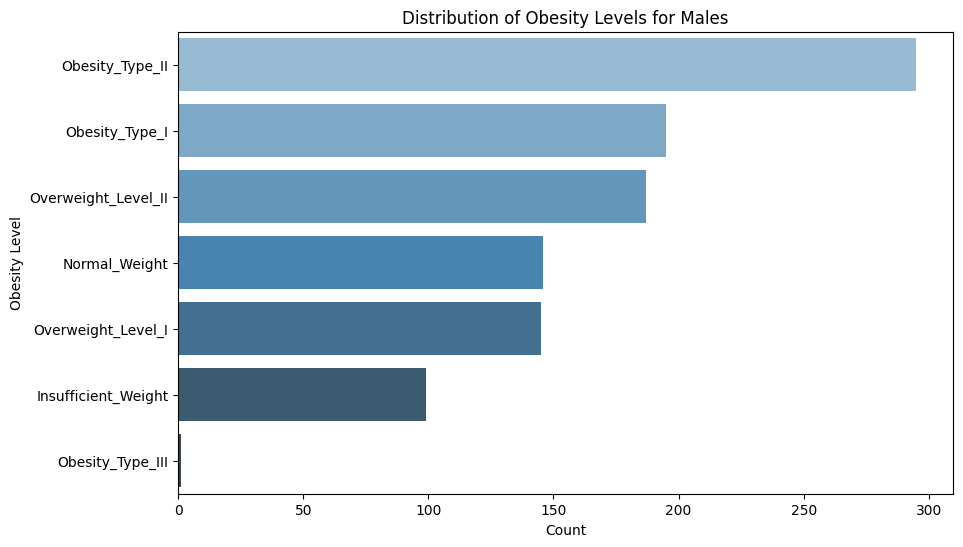

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(y=y_male['NObeyesdad'], order=y_male['NObeyesdad'].value_counts().index, palette='Blues_d')
plt.title('Distribution of Obesity Levels for Males')
plt.xlabel('Count')
plt.ylabel('Obesity Level')
plt.show()

### Obesity Level Distribution for Females

/tmp/ipykernel_22970/2222433794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y_female['NObeyesdad'], order=y_female['NObeyesdad'].value_counts().index, palette='Reds_d')


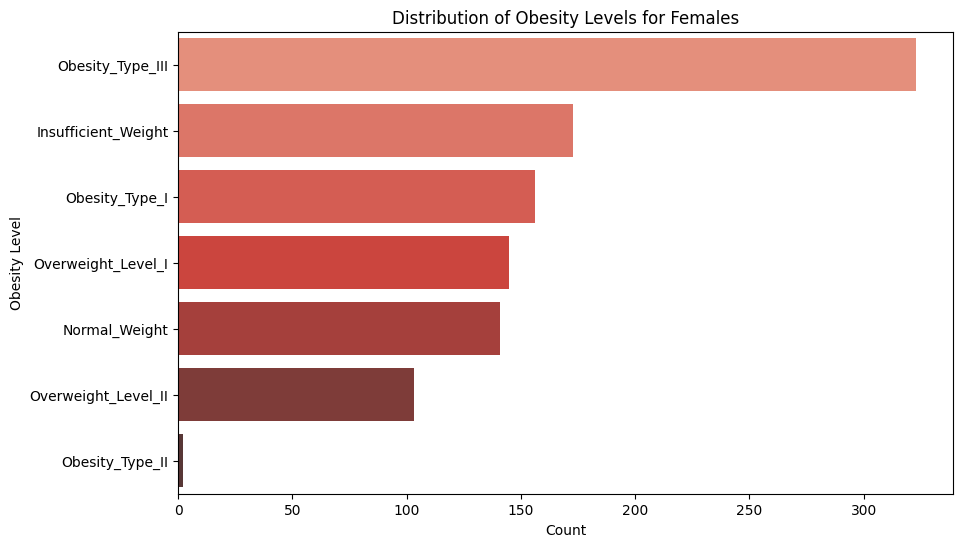

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(y=y_female['NObeyesdad'], order=y_female['NObeyesdad'].value_counts().index, palette='Reds_d')
plt.title('Distribution of Obesity Levels for Females')
plt.xlabel('Count')
plt.ylabel('Obesity Level')
plt.show()

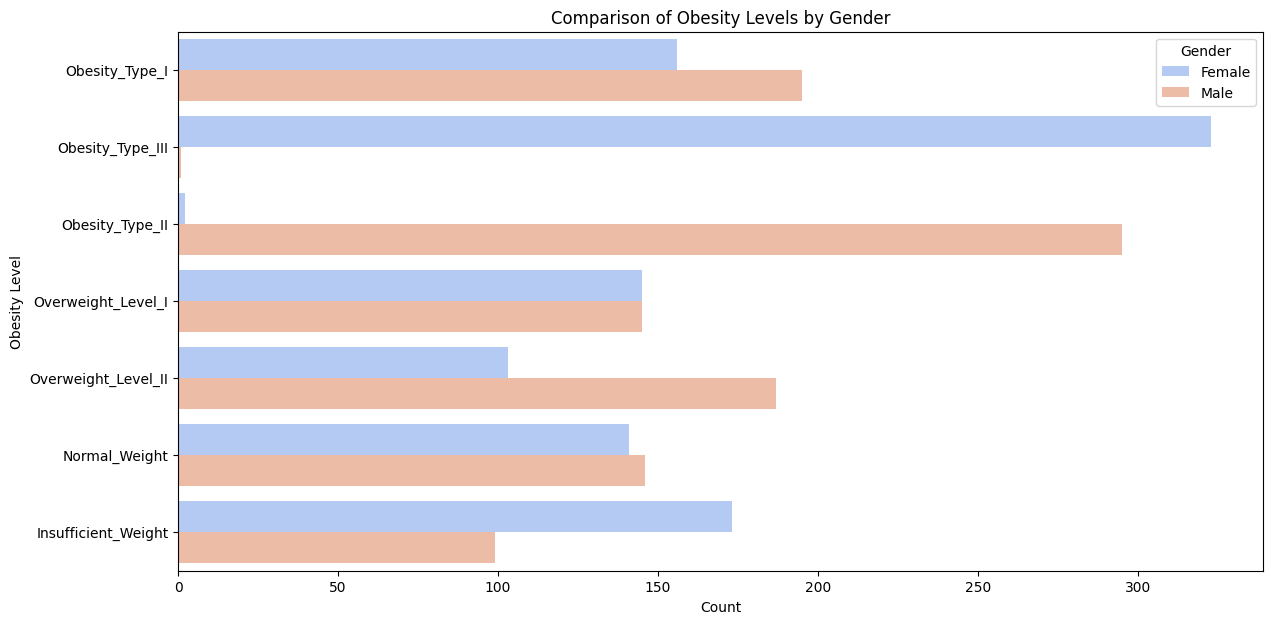

In [28]:
# Combine X and y for easier comparison
combined_df = X.copy()
combined_df['NObeyesdad'] = y['NObeyesdad']

plt.figure(figsize=(14, 7))
sns.countplot(y='NObeyesdad', hue='Gender', data=combined_df, order=combined_df['NObeyesdad'].value_counts().index, palette='coolwarm')
plt.title('Comparison of Obesity Levels by Gender')
plt.xlabel('Count')
plt.ylabel('Obesity Level')
plt.legend(title='Gender')
plt.show()

In [29]:
obesity_gender_distribution = combined_df.groupby(['Gender', 'NObeyesdad']).size().unstack(fill_value=0)
obesity_gender_distribution_percentage = obesity_gender_distribution.apply(lambda x: x / x.sum() * 100, axis=1)
display(obesity_gender_distribution_percentage)

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,16.586769,13.518696,14.956855,0.191755,30.968360,13.902205,9.875360
Male,9.269663,13.670412,18.258427,27.621723,0.093633,13.576779,17.509363


In [30]:
obesity_levels = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
above_obesity_height_filtered = combined_df[(combined_df['NObeyesdad'].isin(obesity_levels)) & (combined_df['Height'] > 5.5)]

count_above_obesity_height = len(above_obesity_height_filtered)
print(f"Number of individuals above obesity with height > 5.5: {count_above_obesity_height}")

Number of individuals above obesity with height > 5.5: 0


In [31]:
obesity_levels = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
above_obesity_age_filtered = combined_df[(combined_df['NObeyesdad'].isin(obesity_levels)) & (combined_df['Age'] > 18)]

count_above_obesity_age = len(above_obesity_age_filtered)
print(f"Number of individuals above obesity with age > 18: {count_above_obesity_age}")

Number of individuals above obesity with age > 18: 932


In [33]:
obesity_levels = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
obese_individuals_info = combined_df[combined_df['NObeyesdad'].isin(obesity_levels)][['Age', 'Height', 'Gender', 'NObeyesdad']]
display(obese_individuals_info.head())

,Age,Height,Gender,NObeyesdad
10,26.0,1.85,Male,Obesity_Type_I
13,41.0,1.80,Male,Obesity_Type_I
17,29.0,1.53,Female,Obesity_Type_I
21,52.0,1.69,Female,Obesity_Type_I
23,22.0,1.60,Female,Obesity_Type_I


In [34]:
obesity_levels = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
obese_individuals_info = combined_df[combined_df['NObeyesdad'].isin(obesity_levels)][['Age', 'Height', 'Gender', 'NObeyesdad']]
display(obese_individuals_info.describe(include='all'))

,Age,Height,Gender,NObeyesdad
count,972.000000,972.000000,972,972
unique,NaN,NaN,2,3
top,NaN,NaN,Male,Obesity_Type_I
freq,NaN,NaN,491,351
mean,25.806181,1.715553,NaN,NaN
std,5.918980,0.088995,NaN,NaN
min,15.000000,1.500000,NaN,NaN
25%,21.681806,1.640744,NaN,NaN
50%,25.138276,1.724095,NaN,NaN
75%,27.933529,1.780193,NaN,NaN


This table shows the first few entries of individuals who are classified as obese, along with their age, height, and gender. If you want to see summary statistics for these groups, let me know!